# Dominio 2: Minería (COCHILCO)

Producción mensual real de cobre de mina por empresa, publicada por COCHILCO
(Comisión Chilena del Cobre) en un Excel que replica el layout visual de un
reporte institucional -- 150 meses reales (2014-01 a 2026-06), 38 faenas/
empresas mineras reales tras excluir columnas subtotal.

Este notebook ejecuta el pipeline real de `src/domains/mining_cochilco/`.


## 1. Limpieza: 3 problemas de ESTRUCTURA, no de dato ausente

1. Filas título/anuales/plantilla mezcladas entre las filas mensuales reales
   -- se filtran por el TIPO del valor de fecha (`datetime` real vs. texto
   que solo *parece* fecha), no por si `pd.to_datetime` logra parsearlo.
2. Filas plantilla de meses futuros aún no publicados (`TOTAL CHILE = 0`).
3. Columnas subtotal DISFRAZADAS -- además de `Total Codelco`/`TOTAL CHILE`
   (obvias por nombre), `Chuqui y R.Tomic`, `Angloamerican Sur` y
   `Capstone Copper` son subtotales de otras columnas, confirmados por
   identidad numérica exacta fila a fila, no por el nombre.


In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
from src.domains.mining_cochilco.clean import build_clean_panel

panel, report = build_clean_panel()
for k, v in report.items():
    if not isinstance(v, pd.DataFrame):
        print(f"{k}: {v}")


filas_no_mensuales_descartadas: 15
filas_futuras_no_publicadas_descartadas: 6
n_filas_mensuales_reales: 150
nombres_empresa_unificados: 0
desviacion_max_total_nacional_vs_publicado: 0.0
nulos_en_columnas_de_empresa: 0
outliers_empresa_mes_detectados_no_recortados: 50
nota_outliers: Detectados pero NO recortados: dato oficial de un regulador, sin evidencia de error de captura (a diferencia de la UF corrupta de financial_bcch) -- recortarlos borraría ciclos operacionales reales (huelgas, mantenciones, rampas de inicio/cierre de faena).
missingness_antes: columna
fecha                       0.0
Chuqui y R.Tomic            0.0
Chuquicamata                0.0
Radomiro Tomic              0.0
Ministro Hales              0.0
Salvador                    0.0
Andina                      0.0
El Teniente                 0.0
Gabriela Mistral            0.0
Total Codelco               0.0
Escondida                   0.0
Spence                      0.0
Cerro Colorado              0.0
Lomas Bayas      

**Validación real**: sumando solo las 38 columnas de faena reales (excluidas
las 4 columnas subtotal disfrazadas), el total nacional calculado coincide
con el `TOTAL CHILE` publicado por COCHILCO con una desviación máxima de
1.1e-13 en las 150 filas -- confirmación numérica, no solo de nombre de
columna, de que el filtro de subtotales es correcto.


## 2. Features y modelado (>=100 épocas)


In [2]:
from src.domains.mining_cochilco.features import build_features
from src.domains.mining_cochilco.model import train_all_models

features_df = build_features(panel)
print(f"{len(features_df):,} filas x features")
features_df.tail()


137 filas x features


,fecha,Chuqui y R.Tomic,Chuquicamata,Radomiro Tomic,Ministro Hales,Salvador,Andina,El Teniente,Gabriela Mistral,Total Codelco,...,total_lag6,total_lag12,total_rolling_mean_3m,total_rolling_mean_6m,total_rolling_mean_12m,mes,anio,yoy_growth,seasonal_naive_pred,target_next_total
132,2026-01-01,38.640,13.577,25.063,8.983,4.002,15.782,18.148,5.478,91.033,...,441.641000,422.745,472.193437,455.215820,449.011910,1,2026,-0.030255,394.476,375.392
133,2026-02-01,32.967,13.958,19.009,9.048,3.693,8.932,21.553,3.657,79.850,...,419.771000,394.476,456.912306,449.934820,447.946077,2,2026,-0.048378,473.908,431.377
134,2026-03-01,43.592,16.062,27.530,8.812,4.034,17.846,19.397,7.077,100.758,...,453.302608,473.908,432.440087,442.538320,446.355743,3,2026,-0.089745,460.673,396.902
135,2026-04-01,36.743,10.622,26.121,7.945,3.319,14.088,19.982,7.114,89.191,...,455.798393,460.673,405.574667,438.884052,442.811493,4,2026,-0.138430,483.038,423.689
136,2026-05-01,39.464,13.745,25.719,9.199,2.484,16.213,23.763,6.382,97.505,...,448.808657,483.038,401.223667,429.067986,437.497243,5,2026,-0.122866,422.008,444.109


In [3]:
output = train_all_models(features_df)
pd.DataFrame(output["results"]).T


,r2,rmse,mae,epochs_run,best_epoch,early_stopped,best_iteration
baseline_estacional,0.128882,39.609008,35.41462,NaN,NaN,NaN,NaN
mlp_pytorch,0.251525,36.715051,28.609163,136,111,True,NaN
xgboost,0.514606,29.566679,23.800091,NaN,NaN,NaN,197.0


**Resultado real**: XGBoost (R²=0.515) supera claramente tanto al baseline
estacional (mismo mes, año anterior; R²=0.129) como a la MLP (R²=0.252) --
ambos modelos reales le ganan al baseline por un margen genuino. La MLP tuvo
que escalar también el TARGET (no solo las features) con `zscore_scale`: sin
eso, con el target en su escala real (~450 miles de toneladas), la red
predecía valores entre R²=-77 incluso usando `LeakyReLU` -- un gotcha
distinto del "dying ReLU" del dominio financiero, mismo síntoma
(colapso numérico), causa distinta (escala del target, no de la activación).


## 3. Gráficos


**Nulos por columna, antes/después de limpiar** -- confirma que no hay celdas realmente vacías en las filas mensuales reales.


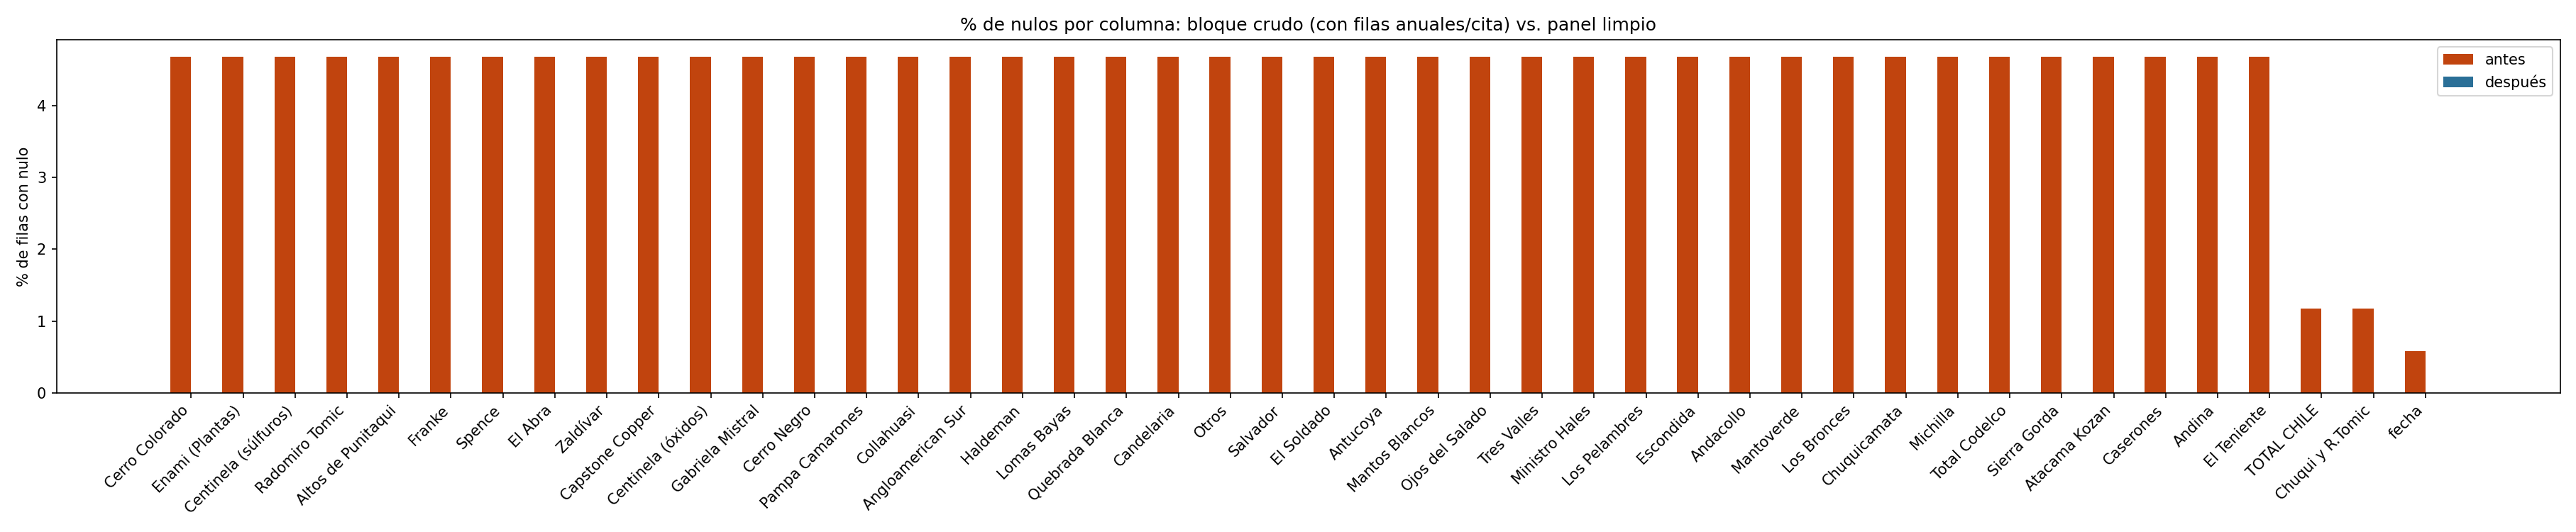

In [4]:
from IPython.display import Image, display
display(Image(filename="../outputs/mining/figures/missingness_before_after.png"))


**Distribución de producción por faena, antes/después de winsorizar outliers dentro de cada empresa** (k=3.0, solo meses no-cero).


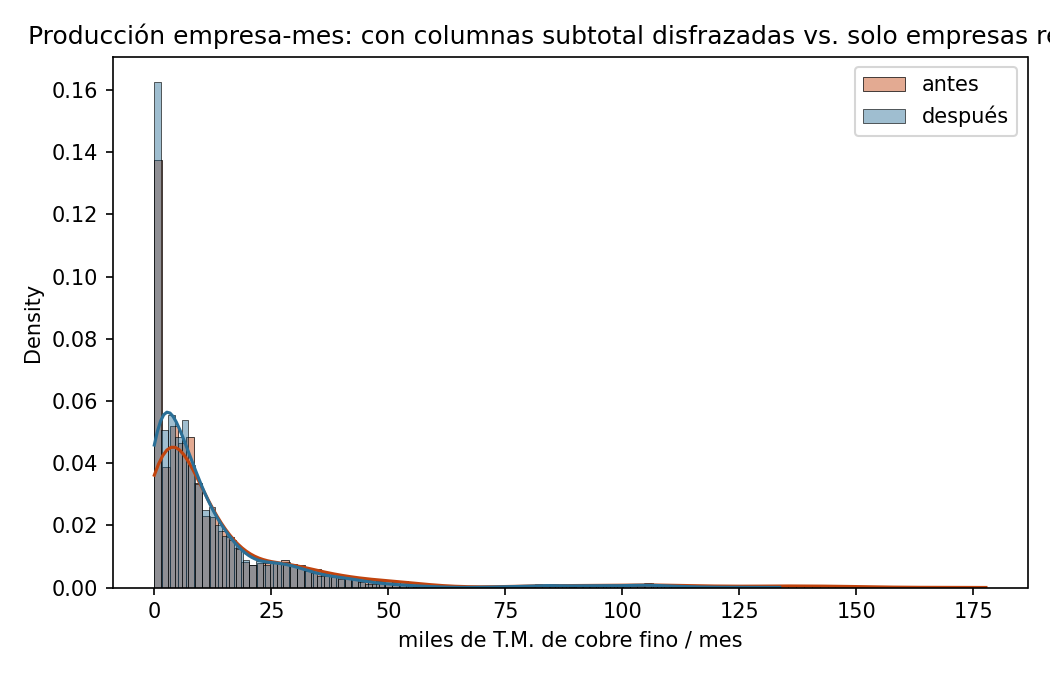

In [5]:
from IPython.display import Image, display
display(Image(filename="../outputs/mining/figures/production_distribution_before_after.png"))


**Producción nacional mensual real de cobre, 2014-2026.**


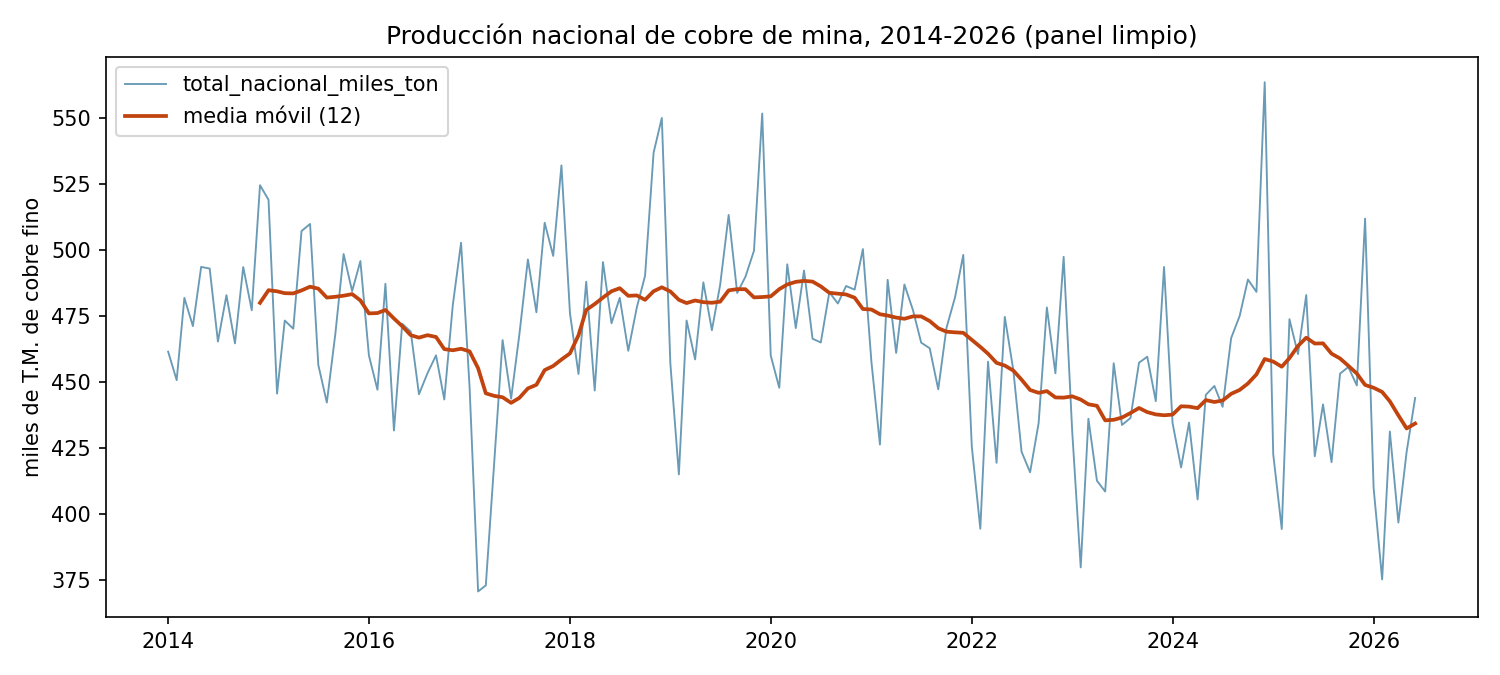

In [6]:
from IPython.display import Image, display
display(Image(filename="../outputs/mining/figures/produccion_nacional_timeseries.png"))


**Correlación entre features y la producción nacional del mes siguiente.**


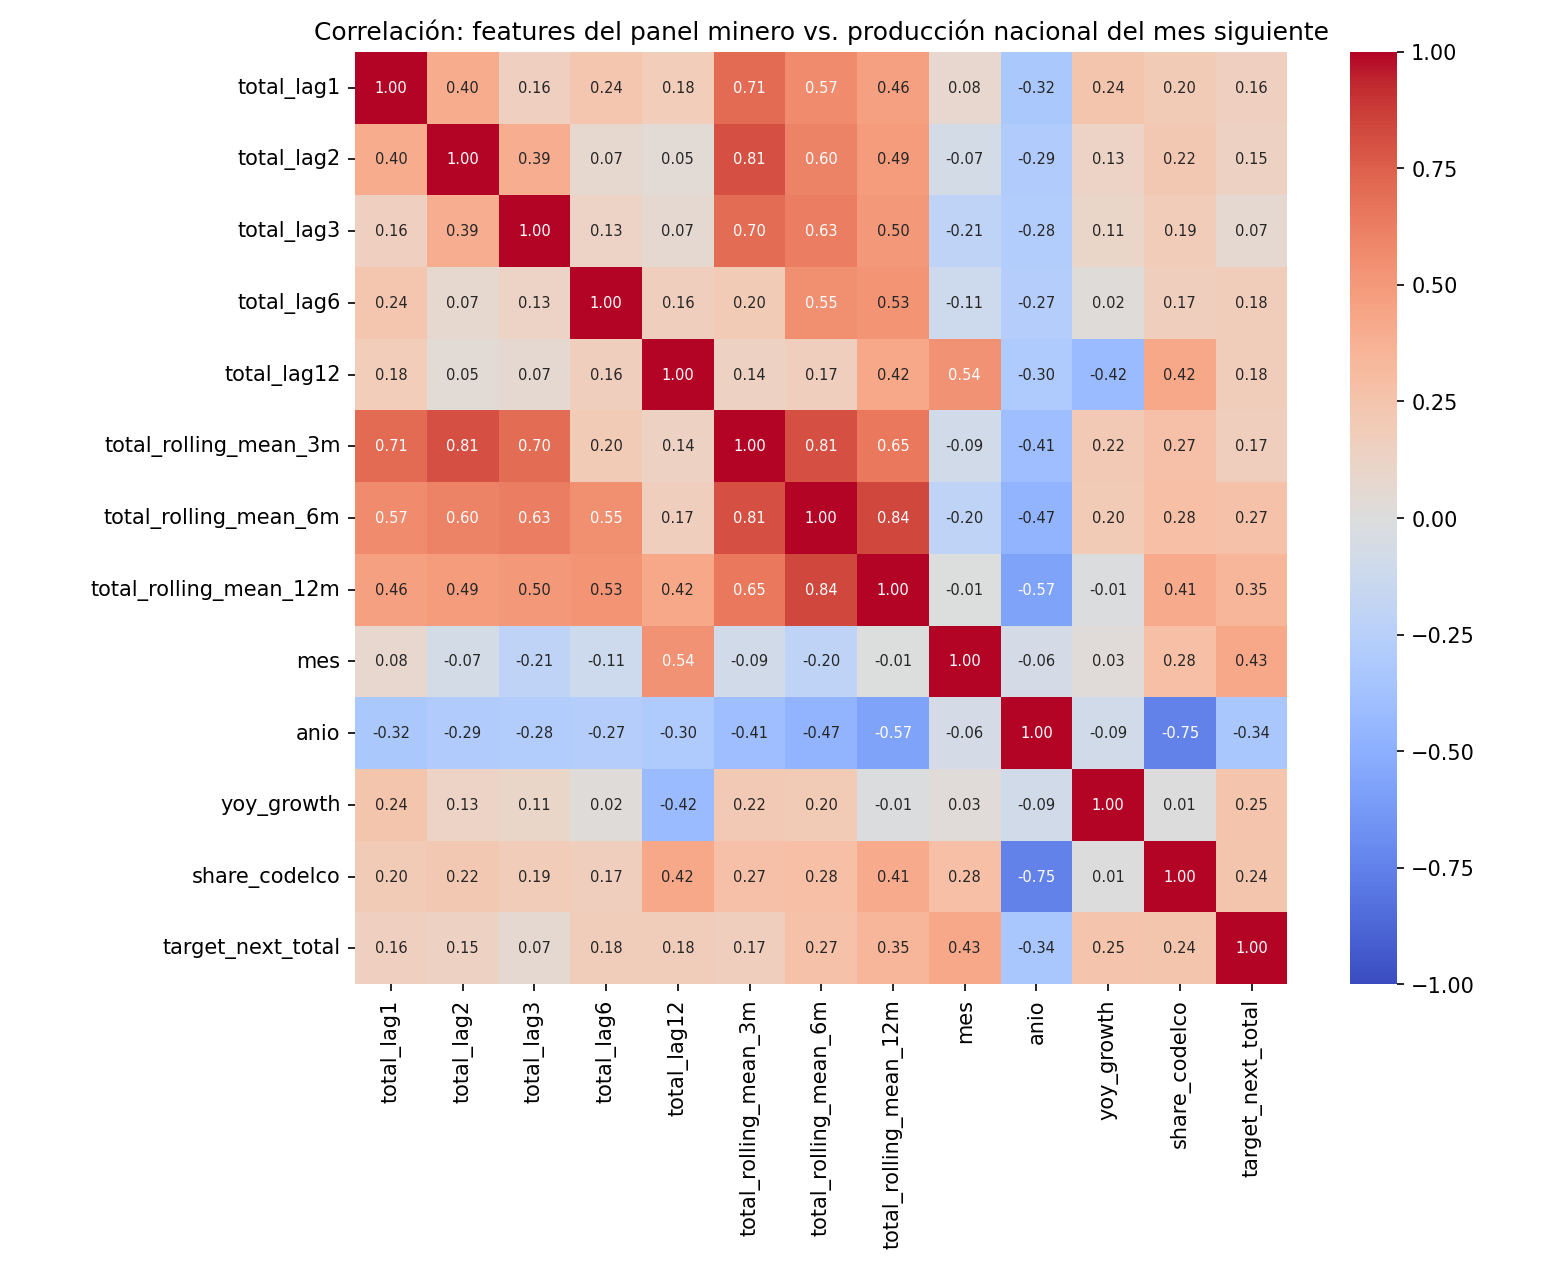

In [7]:
from IPython.display import Image, display
display(Image(filename="../outputs/mining/figures/feature_correlation.png"))


**Curva de entrenamiento de la MLP** -- >=100 épocas hasta activar early stopping (mejor época=111).


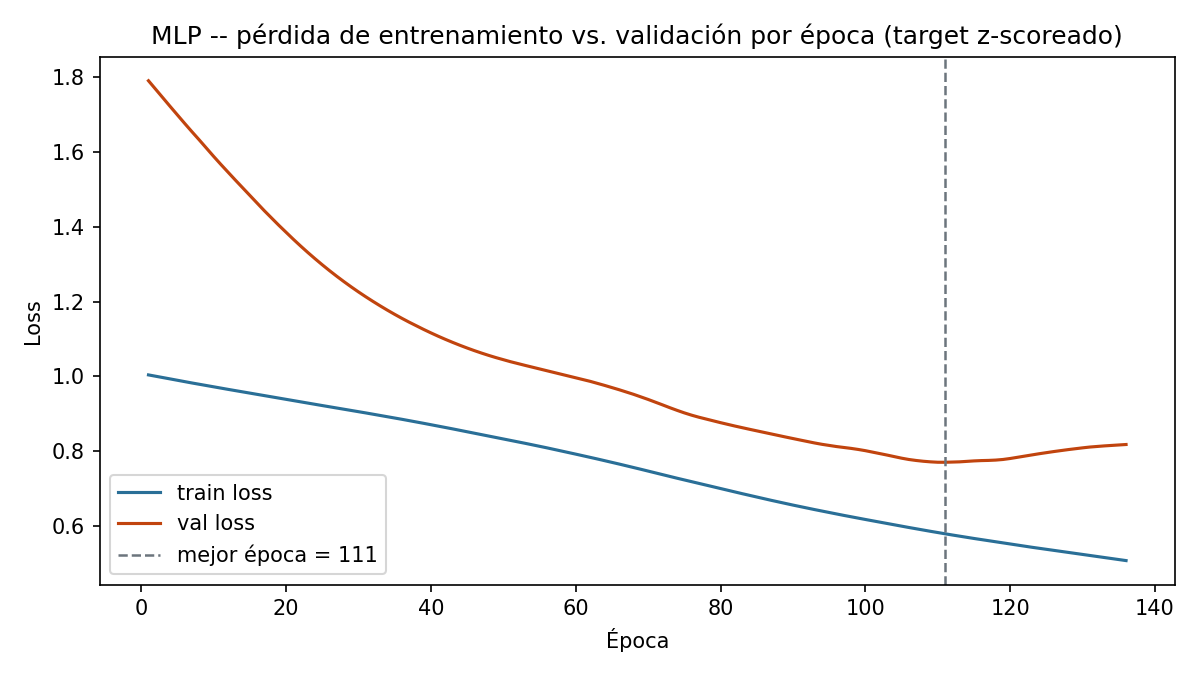

In [8]:
from IPython.display import Image, display
display(Image(filename="../outputs/mining/figures/mlp_training_curve.png"))


**Producción real vs. predicha (XGBoost, holdout cronológico).**


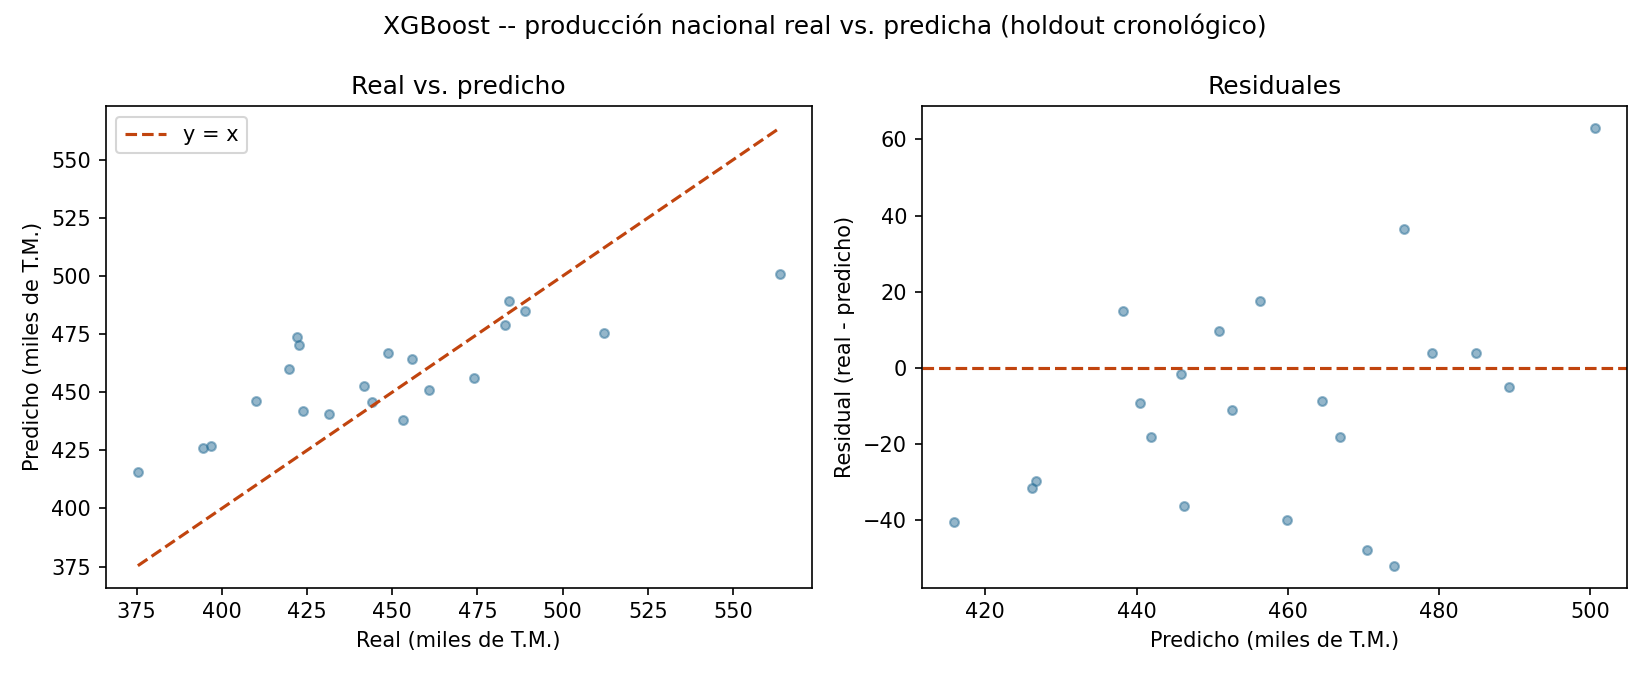

In [9]:
from IPython.display import Image, display
display(Image(filename="../outputs/mining/figures/xgboost_regression_diagnostics.png"))


**Comparación baseline estacional vs. MLP vs. XGBoost.**


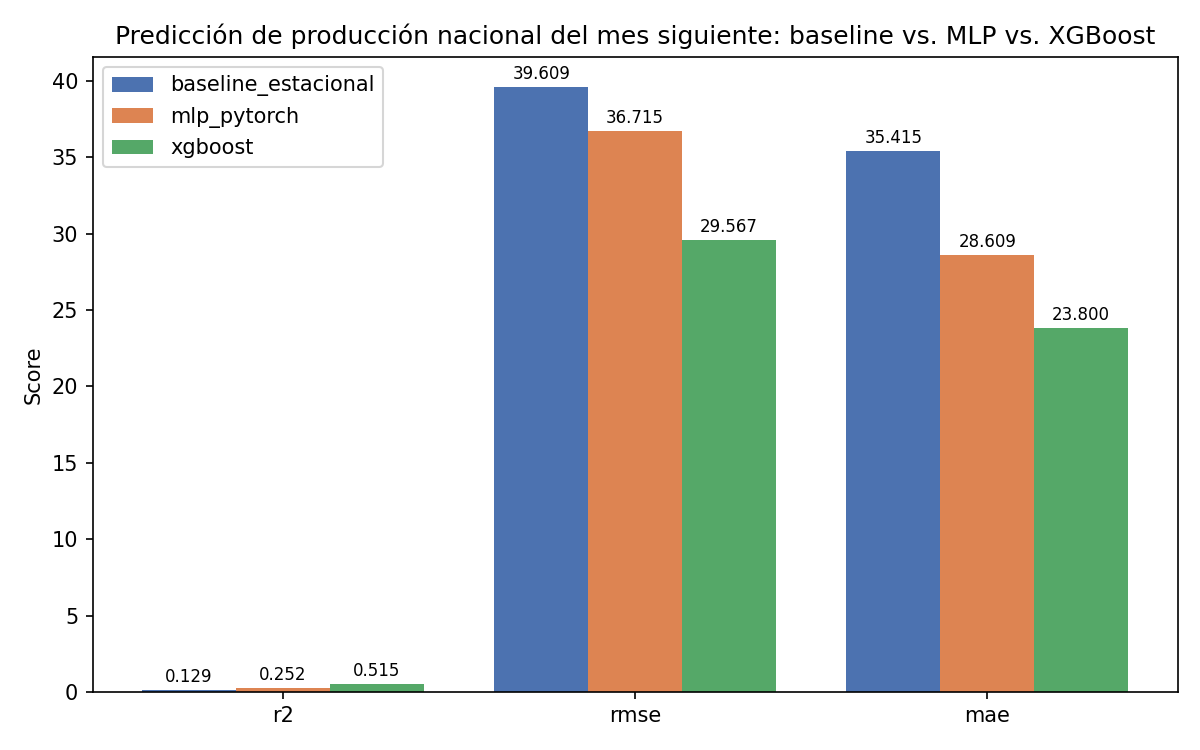

In [10]:
from IPython.display import Image, display
display(Image(filename="../outputs/mining/figures/model_comparison.png"))


## Conclusiones

- El desafío de limpieza central en Excel institucional real no es el dato
  faltante -- es la ESTRUCTURA: filas que no son observaciones, columnas que
  son subtotales disfrazados de faena. Ambos se detectan con lógica de tipo/
  identidad numérica, no con reglas de nombre de columna.
- XGBoost captura estacionalidad + tendencia real de forma clara; ambos
  modelos reales superan a un baseline estacional ingenuo.
